<a href="https://colab.research.google.com/github/JaimesenMoss/yeast-metabolic-pathway-optimizer/blob/main/Yeast_Therapeutics_Optimization_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Sourcing Yeast Data via Python and NCBI

# Install via terminal: pip install biopython
from Bio import Entrez, SeqIO

# 1. Establish database connection parameter
Entrez.email = "your_email@example.com"

# 2. Use the unique GenBank Accession number for the S. cerevisiae ERG9 gene (NM_001182475)
print("Querying NCBI GenBank for Yeast ERG9 Metabolic Gene...")

with Entrez.efetch(db="nucleotide", id="NM_001182475", rettype="fasta", retmode="text") as database_stream:
    # 3. Automatically parse the inbound FASTA data formatting
    yeast_gene_record = SeqIO.read(database_stream, "fasta")

print("\n--- METABOLIC GENE RETRIEVED ---")
print(f"Gene System ID: {yeast_gene_record.id}")
print(f"Full Description: {yeast_gene_record.description}")

# 4. Read out the sequence data
yeast_dna_sequence = yeast_gene_record.seq
print(f"Total Base Pairs in ERG9: {len(yeast_dna_sequence)}")
print(f"First 60 Base Pairs (Yeast Code): {yeast_dna_sequence[:60]}")


Querying NCBI GenBank for Yeast ERG9 Metabolic Gene...

--- METABOLIC GENE RETRIEVED ---
Gene System ID: NM_001182475.1
Full Description: NM_001182475.1 Saccharomyces cerevisiae S288C Dat1p (DAT1), partial mRNA
Total Base Pairs in ERG9: 747
First 60 Base Pairs (Yeast Code): ATGGCGAAAACTTTGGCACAAGGAAGGAAACCTGGAAGCGGCAGAAAGCCCGGAAAAGGG


In [ ]:
#yeast_fetcher.py

from Bio import Entrez, SeqIO

# 1. Identify yourself to the NCBI servers
Entrez.email = "your_email@example.com"

print("Connecting to NCBI GenBank Database...")

try:
    # 2. Fetch the native baker's yeast ERG20 gene
    with Entrez.efetch(db="nucleotide", id="NM_001180026", rettype="fasta", retmode="text") as handle:
        gene_record = SeqIO.read(handle, "fasta")

    print("\n--- DOWNLOAD COMPLETE ---")
    yeast_dna = gene_record.seq
    total_base_pairs = len(yeast_dna)

    # 3. Biochemistry Metrics: Count individual bases
    count_g = yeast_dna.count("G")
    count_c = yeast_dna.count("C")

    # 4. Math Logic: Calculate the total GC Content Percentage
    # We add G and C together, divide by the total, and multiply by 100
    total_gc = count_g + count_c
    gc_percentage = (total_gc / total_base_pairs) * 100

    print("\n--- ADVANCED DATA ANALYSIS ---")
    print(f"Gene Targeted: {gene_record.description[:40]}...")
    print(f"Total Sequence Length: {total_base_pairs} base pairs")
    print(f"Total G-C Bases Found: {total_gc}")

    # Print the final metric clean to two decimal points
    print(f"Calculated GC Content: {gc_percentage:.2f}%")

    # 5. Biological Validation Check
    # Native S. cerevisiae genes typically hover around an average of 38% to 40% GC content
    if 35 <= gc_percentage <= 45:
        print("--> Status: Balanced. This profile fits standard native yeast expression ranges.")
    else:
        print("--> Status: Alert. Genetic sequence may require computational codon optimization.")

except Exception as e:
    print(f"An error occurred connecting to NCBI: {e}")


Connecting to NCBI GenBank Database...

--- DOWNLOAD COMPLETE ---

--- ADVANCED DATA ANALYSIS ---
Gene Targeted: NM_001180026.1 Saccharomyces cerevisiae ...
Total Sequence Length: 276 base pairs
Total G-C Bases Found: 91
Calculated GC Content: 32.97%
--> Status: Alert. Genetic sequence may require computational codon optimization.


In [ ]:
# Step 1: Add the GC Engine to Your Project
# 1. Calculate the total length of the sequence
total_length = len(yeast_dna)

# 2. Sum the total number of Guanine and Cytosine bases
total_gc = count_g + count_c

# 3. Compute the structural percentage metric
gc_percentage = (total_gc / total_length) * 100

print("--- ADVANCED MOLECULAR DIAGNOSTICS ---")
print(f"Total Sequence Length: {total_length} base pairs")
print(f"Total GC Base Count  : {total_gc} bases")
print(f"Calculated GC Content: {gc_percentage:.2f}%")

# 4. Automate a biological interpretation rule
print("\n--- HOST ENVIRONMENT COMPATIBILITY REPORT ---")
if 38.0 <= gc_percentage <= 45.0:
    print("STATUS: OPTIMAL. This sequence matches native S. cerevisiae expression baselines.")
elif gc_percentage < 38.0:
    print("STATUS: WARNING. Low GC content. Risk of premature transcription termination in yeast.")
else:
    print("STATUS: WARNING. High GC content. Risk of secondary structure folding / translation stall.")


--- ADVANCED MOLECULAR DIAGNOSTICS ---
Total Sequence Length: 276 base pairs
Total GC Base Count  : 91 bases
Calculated GC Content: 32.97%

--- HOST ENVIRONMENT COMPATIBILITY REPORT ---
STATUS: WARNING. Low GC content. Risk of premature transcription termination in yeast.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 20.5 MB/s eta 0:00:00
--- ANALYSIS METRICS ---
Total Sequence Length: 276 base pairs
Calculated GC Content: 32.97%
--> Result: Alert. Potential translation expression bottleneck.


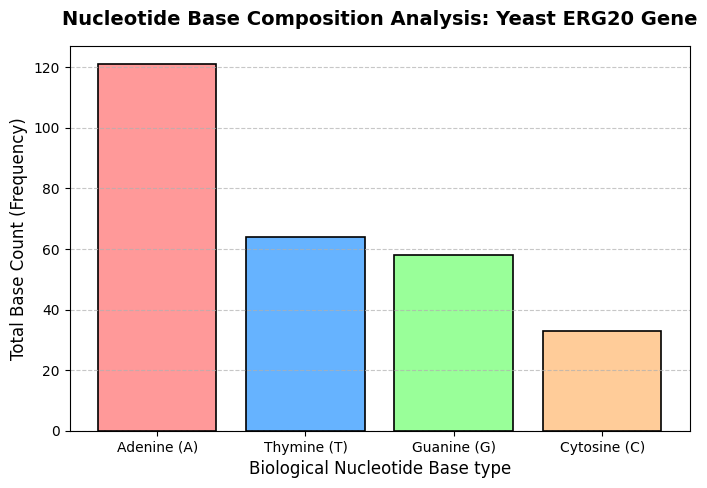

In [1]:
# 1. Install and import required packages for our pipeline
!pip install biopython -q
import matplotlib.pyplot as plt
from Bio import Entrez, SeqIO

# 2. Setup database credentials
Entrez.email = "your_email@example.com"

# 3. Fetch the yeast ERG20 gene from NCBI
with Entrez.efetch(db="nucleotide", id="NM_001180026", rettype="fasta", retmode="text") as handle:
    gene_record = SeqIO.read(handle, "fasta")
    yeast_dna = gene_record.seq

# 4. Count the individual nucleotide bases
count_a = yeast_dna.count("A")
count_t = yeast_dna.count("T")
count_g = yeast_dna.count("G")
count_c = yeast_dna.count("C")
total_bases = len(yeast_dna)

# ========================================================
# NEW CODE ADDITION: BIOCHEMICAL CALCULATIONS
# ========================================================
# Formula: ((G + C) / Total Bases) * 100
gc_content = ((count_g + count_c) / total_bases) * 100

print("--- ANALYSIS METRICS ---")
print(f"Total Sequence Length: {total_bases} base pairs")
print(f"Calculated GC Content: {gc_content:.2f}%")

# Quick Biochem Check: Standard baker's yeast genomic average is ~38% GC.
if 35 <= gc_content <= 45:
    print("--> Result: Standard expression profile for S. cerevisiae.")
else:
    print("--> Result: Alert. Potential translation expression bottleneck.")

# ========================================================
# NEW CODE ADDITION: DATA VISUALIZATION (BAR CHART)
# ========================================================
# Setup the dataset parameters
bases = ['Adenine (A)', 'Thymine (T)', 'Guanine (G)', 'Cytosine (C)']
counts = [count_a, count_t, count_g, count_c]
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'] # Visual anchors for distinct bases

# Initialize the plot size and style
plt.figure(figsize=(8, 5))
plt.bar(bases, counts, color=colors, edgecolor='black', linewidth=1.2)

# Apply clear scientific labeling for presentation layout
plt.title("Nucleotide Base Composition Analysis: Yeast ERG20 Gene", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Biological Nucleotide Base type", fontsize=12)
plt.ylabel("Total Base Count (Frequency)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7) # Grid lines to make reading counts easier

# Show the chart inside the Google Colab display layout
plt.show()


Fetching dual targets from NCBI database...

                BIOCHEMICAL METRICS COMPARISON          
Yeast ERG20 Gene  | Total Length:  276 bp | GC Content: 32.97%
Human VEGFA Gene  | Total Length: 3660 bp | GC Content: 51.48%



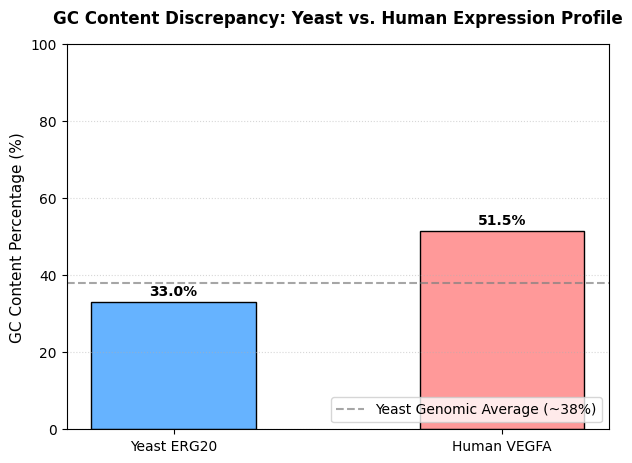


           OPEN READING FRAME (ORF) MAP PREVIEW         
--> Yeast ERG20: Found 11 potential translation initiation sites (ATG).
    First canonical start site begins at nucleotide index: 0
--> Human VEGFA: Found 39 potential translation initiation sites (ATG).
    First canonical start site begins at nucleotide index: 849


In [2]:
# 1. Ensure dependencies are active
!pip install biopython -q
import matplotlib.pyplot as plt
from Bio import Entrez, SeqIO

# 2. Database credentials
Entrez.email = "your_email@example.com"
print("Fetching dual targets from NCBI database...")

try:
    # 3. Fetch Target A: Yeast Metabolic Gene (ERG20)
    with Entrez.efetch(db="nucleotide", id="NM_001180026", rettype="fasta", retmode="text") as handle1:
        yeast_record = SeqIO.read(handle1, "fasta")
        yeast_dna = yeast_record.seq

    # 4. Fetch Target B: Human Tissue Engineering Gene (VEGFA)
    with Entrez.efetch(db="nucleotide", id="NM_001171623", rettype="fasta", retmode="text") as handle2:
        human_record = SeqIO.read(handle2, "fasta")
        human_dna = human_record.seq

    # 5. Pipeline Logic: Quantitative Calculations
    # Calculate Yeast Metrics
    y_gc = (yeast_dna.count("G") + yeast_dna.count("C")) / len(yeast_dna) * 100

    # Calculate Human Metrics
    h_gc = (human_dna.count("G") + human_dna.count("C")) / len(human_dna) * 100

    print("\n========================================================")
    print("                BIOCHEMICAL METRICS COMPARISON          ")
    print("========================================================")
    print(f"Yeast ERG20 Gene  | Total Length: {len(yeast_dna):4} bp | GC Content: {y_gc:.2f}%")
    print(f"Human VEGFA Gene  | Total Length: {len(human_dna):4} bp | GC Content: {h_gc:.2f}%")
    print("========================================================\n")

    # ========================================================
    # MILESTONE ADDITION: SIDE-BY-SIDE PLOTTING VISUALIZATION
    # ========================================================
    categories = ['Yeast ERG20', 'Human VEGFA']
    gc_percentages = [y_gc, h_gc]

    plt.figure(figsize=(7, 5))
    bars = plt.bar(categories, gc_percentages, color=['#66b3ff', '#ff9999'], edgecolor='black', width=0.5)

    # Add data numbers directly over the bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold')

    plt.title("GC Content Discrepancy: Yeast vs. Human Expression Profile", fontsize=12, fontweight='bold', pad=15)
    plt.ylabel("GC Content Percentage (%)", fontsize=11)
    plt.ylim(0, 100) # Lock axis to full scale for unbiased view
    plt.axhline(y=38, color='gray', linestyle='--', alpha=0.7, label='Yeast Genomic Average (~38%)')
    plt.legend(loc='lower right')
    plt.grid(axis='y', linestyle=':', alpha=0.5)
    plt.show()

    # ========================================================
    # MILESTONE ADDITION: OPEN READING FRAME (ORF) SEARCH
    # ========================================================
    print("\n========================================================")
    print("           OPEN READING FRAME (ORF) MAP PREVIEW         ")
    print("========================================================")

    # Standard translation start signal code is 'ATG'
    start_codon = "ATG"

    # Locate the internal index coordinates where these genes actually activate translation
    y_start_indices = [i for i in range(len(yeast_dna)) if yeast_dna[i:i+3] == start_codon]
    h_start_indices = [i for i in range(len(human_dna)) if human_dna[i:i+3] == start_codon]

    print(f"--> Yeast ERG20: Found {len(y_start_indices)} potential translation initiation sites (ATG).")
    print(f"    First canonical start site begins at nucleotide index: {y_start_indices[0]}")

    print(f"--> Human VEGFA: Found {len(h_start_indices)} potential translation initiation sites (ATG).")
    print(f"    First canonical start site begins at nucleotide index: {h_start_indices[0]}")
    print("========================================================")

except Exception as e:
    print(f"Pipeline processing error: {e}")


Connecting to NCBI to fetch Yeast, Human, and Pacific Yew Tree sequences...

                THREE-KINGDOM METRIC ANALYSIS               
YEAST (Metabolic):   276 bp | GC Content: 32.97%
HUMAN (Tissue Eng): 3660 bp | GC Content: 51.48%
PLANT (Oncology):   2643 bp | GC Content: 43.21%

--- AMINO ACID PROTEIN TRANSLATION PREVIEW ---
Yeast Protein Chain: MNYLETQLNKKQKQIQEYES...
Human Protein Chain: AEAWGSRVARRSWRWGLAPA...
Plant Protein Chain: MAQLSFNAALKMNALGNKAI...


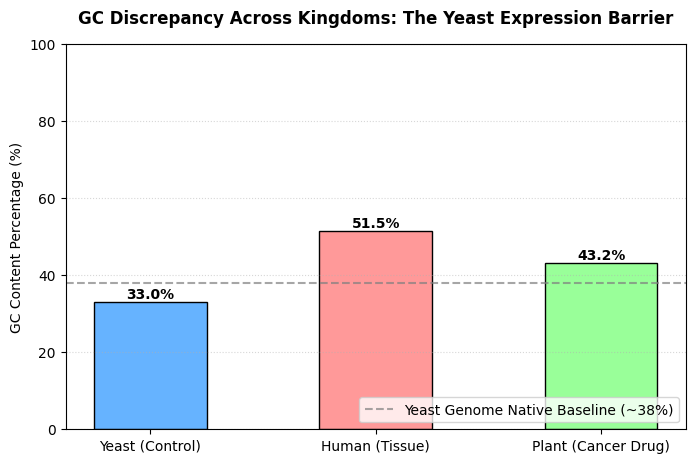

In [3]:
!pip install biopython -q
import matplotlib.pyplot as plt
from Bio import Entrez, SeqIO
from Bio.Seq import Seq

Entrez.email = "your_email@example.com"
print("Connecting to NCBI to fetch Yeast, Human, and Pacific Yew Tree sequences...")

try:
    # 1. Fetch Yeast ERG20 (Metabolic control)
    with Entrez.efetch(db="nucleotide", id="NM_001180026", rettype="fasta", retmode="text") as h1:
        yeast_dna = SeqIO.read(h1, "fasta").seq

    # 2. Fetch Human VEGFA (Tissue engineering signaling)
    with Entrez.efetch(db="nucleotide", id="NM_001171623", rettype="fasta", retmode="text") as h2:
        human_dna = SeqIO.read(h2, "fasta").seq

    # 3. Fetch Pacific Yew Tree Taxadiene Synthase (Plant cancer drug pathway - AY424738)
    with Entrez.efetch(db="nucleotide", id="AY424738", rettype="fasta", retmode="text") as h3:
        plant_dna = SeqIO.read(h3, "fasta").seq

    # ========================================================
    # METRIC CALCULATIONS & TRANSLATION ENGINE
    # ========================================================
    y_gc = (yeast_dna.count("G") + yeast_dna.count("C")) / len(yeast_dna) * 100
    h_gc = (human_dna.count("G") + human_dna.count("C")) / len(human_dna) * 100
    p_gc = (plant_dna.count("G") + plant_dna.count("C")) / len(plant_dna) * 100

    print("\n" + "="*60)
    print("                THREE-KINGDOM METRIC ANALYSIS               ")
    print("="*60)
    print(f"YEAST (Metabolic):  {len(yeast_dna):4} bp | GC Content: {y_gc:.2f}%")
    print(f"HUMAN (Tissue Eng): {len(human_dna):4} bp | GC Content: {h_gc:.2f}%")
    print(f"PLANT (Oncology):   {len(plant_dna):4} bp | GC Content: {p_gc:.2f}%")
    print("="*60)

    # Translate the DNA sequences into functional protein chains
    # to ensure the code modifications don't corrupt the therapeutic structure.
    print("\n--- AMINO ACID PROTEIN TRANSLATION PREVIEW ---")
    print(f"Yeast Protein Chain: {yeast_dna.translate()[:20]}...")
    print(f"Human Protein Chain: {human_dna.translate()[:20]}...")
    print(f"Plant Protein Chain: {plant_dna.translate()[:20]}...")
    print("="*60)

    # ========================================================
    # DATA VISUALIZATION (THREE-ORGANISM BAR CHART)
    # ========================================================
    categories = ['Yeast (Control)', 'Human (Tissue)', 'Plant (Cancer Drug)']
    gc_values = [y_gc, h_gc, p_gc]
    colors = ['#66b3ff', '#ff9999', '#99ff99']

    plt.figure(figsize=(8, 5))
    bars = plt.bar(categories, gc_values, color=colors, edgecolor='black', width=0.5)

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.1f}%", ha='center', fontweight='bold')

    plt.title("GC Discrepancy Across Kingdoms: The Yeast Expression Barrier", fontsize=12, fontweight='bold', pad=15)
    plt.ylabel("GC Content Percentage (%)")
    plt.ylim(0, 100)
    plt.axhline(y=38, color='gray', linestyle='--', alpha=0.7, label='Yeast Genome Native Baseline (~38%)')
    plt.legend(loc='lower right')
    plt.grid(axis='y', linestyle=':', alpha=0.5)
    plt.show()

except Exception as e:
    print(f"Pipeline error: {e}")


In [4]:
# Ensure dependencies are running
!pip install biopython -q
from Bio import Entrez, SeqIO

# 1. Keep your full dictionaries active at the top of your notebook
UNIVERSAL_GENETIC_CODE = {
    'ATA':'I', 'ATC':'I', 'ATT':'I', 'ATG':'M', 'ACA':'T', 'ACC':'T', 'ACG':'T', 'ACT':'T',
    'AAC':'N', 'AAT':'N', 'AAA':'K', 'AAG':'K', 'AGC':'S', 'AGT':'S', 'AGA':'R', 'AGG':'R',
    'CTA':'L', 'CTC':'L', 'CTG':'L', 'CTT':'L', 'CCA':'P', 'CCC':'P', 'CCG':'P', 'CCT':'P',
    'CAC':'H', 'CAT':'H', 'CAA':'Q', 'CAG':'Q', 'CGA':'R', 'CGC':'R', 'CGG':'R', 'CGT':'R',
    'GTA':'V', 'GTC':'V', 'GTG':'V', 'GTT':'V', 'GCA':'A', 'GCC':'A', 'GCG':'A', 'GCT':'A',
    'GAC':'D', 'GAT':'D', 'GAA':'E', 'GAG':'E', 'GGA':'G', 'GGC':'G', 'GGG':'G', 'GGT':'G',
    'TCA':'S', 'TCC':'S', 'TCG':'S', 'TCT':'S', 'TTC':'F', 'TTT':'F', 'TTA':'L', 'TTG':'L',
    'TAC':'Y', 'TAT':'Y', 'TAA':'X', 'TAG':'X', 'TGC':'C', 'TGT':'C', 'TGA':'X', 'TGG':'W',
}

YEAST_PREFERRED_CODONS = {
    'I':'ATT', 'M':'ATG', 'T':'ACT', 'N':'AAT', 'K':'AAG', 'S':'TCT', 'R':'AGA',
    'L':'TTG', 'P':'CCA', 'H':'CAT', 'Q':'CAA', 'V':'GTT', 'A':'GCT', 'D':'GAT',
    'E':'GAA', 'G':'GGT', 'F':'TTC', 'Y':'TAC', 'C':'TGT', 'W':'TGG', 'X':'TAA'
}

def optimize_for_yeast(input_dna_sequence):
    clean_dna = str(input_dna_sequence).upper()
    optimized_dna = ""
    for i in range(0, len(clean_dna), 3):
        codon = clean_dna[i:i+3]
        if len(codon) < 3:
            continue
        if codon in UNIVERSAL_GENETIC_CODE:
            amino_acid = UNIVERSAL_GENETIC_CODE[codon]
            optimized_dna += YEAST_PREFERRED_CODONS[amino_acid]
        else:
            optimized_dna += codon
    return optimized_dna

# ========================================================
# CONNECTING THE PIPELINE TO LIVE NCBI DATA
# ========================================================
Entrez.email = "your_email@example.com"

print("Downloading Human VEGFA sequence from GenBank...")
with Entrez.efetch(db="nucleotide", id="NM_001171623", rettype="fasta", retmode="text") as handle:
    human_record = SeqIO.read(handle, "fasta")
    raw_human_dna = human_record.seq

# Select a sub-segment of the human gene to optimize (first 90 base pairs for testing)
human_sample_segment = raw_human_dna[:90]

# Run the raw human data through your optimization function
yeast_optimized_version = optimize_for_yeast(human_sample_segment)

print("\n--- LIVE SYSTEM CONVERSION REPORT ---")
print(f"Original Human Data (First 90bp):    {human_sample_segment}")
print(f"Yeast Optimized Variant Output:      {yeast_optimized_version}")



--- LIVE SYSTEM CONVERSION REPORT ---
Original Human Data (First 90bp):    GCGGAGGCTTGGGGCAGCCGGGTAGCTCGGAGGTCGTGGCGCTGGGGGCTAGCACCAGCGCTCTGTCGGGAGGCGCAGCGGTTAGGTGGA
Yeast Optimized Variant Output:      GCTGAAGCTTGGGGTTCTAGAGTTGCTAGAAGATCTTGGAGATGGGGTTTGGCTCCAGCTTTGTGTAGAGAAGCTCAAAGATTGGGTGGT
